# Auswertung der DLA Daten Bestand Günter Eich (BF000120054)

In [2]:
#!/usr/bin/env python3
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import Counter
import json, re

with open("BF000120054.json", "r", encoding="utf-8") as fh:
    records = json.load(fh)
print( len(records), "Einträge" )
#records[2]

1740 Einträge


Der Bestand **A:Eich, Günter** hat die Mediennummer **BF000120054**.

Für den Bezug des Datenbestands über dataservice muss die letzte Ziffer (Prüfnummer) entfernt werden: 

*collection_id_mv:**BF00012005***

## JSON-Felder

In [3]:
counter = Counter()
types = {}

for record in records:
    counter.update(record.keys())

    for key, value in record.items():
        if key not in types:
            types[key] = type(value).__name__

print(f"{'Feld':35} {'Typ':10} {'Anzahl':>8}")
print("-" * 58)

for field, count in sorted(counter.items(), key=lambda x: (-x[1], x[0])):
    print(f"{field:35} {types[field]:10} {count:8}")

Feld                                Typ          Anzahl
----------------------------------------------------------
collection_display_mv               list           1740
collection_id_mv                    list           1740
dateCataloged                       str            1740
dateModified                        str            1740
display                             str            1740
id                                  str            1740
mediaNumber                         str            1740
schemaVersion                       str            1740
searchBoost                         int            1740
source                              str            1740
statusLoan                          str            1740
url                                 str            1740
usageRestriction                    str            1740
usageRestrictionNote                str            1740
accessionNumber                     str            1739
category                            str      

# zu den einzelnen Feldern

## accessionNumber

Zugangsnummern im DLA Marbach
* ab dem Jahr 1941 wurden Jahreszahlen in der Zugangsnummer verwendet
* ab dem Jahr 1999 wurde im Rahmen der Umstellung auf Datenbankbetrieb HS am Anfang eingesetzt

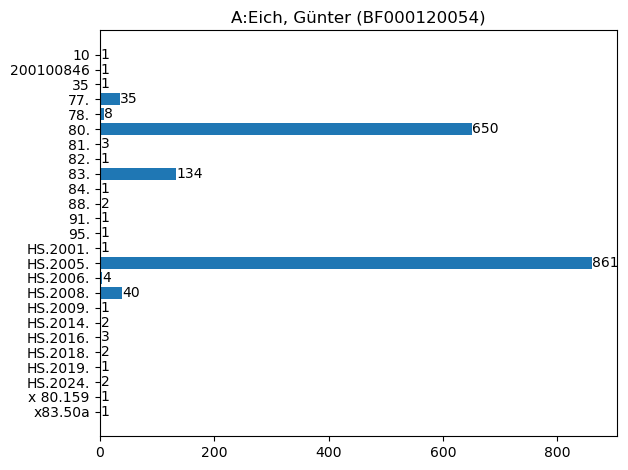

In [9]:
import re
from collections import Counter

def group(a):
    a = a.strip()
    if m := re.match(r"^(\d{2}\.)", a): return m.group(1)
    if m := re.match(r"^HS\.(\d{4}\.)", a): return f"HS.{m.group(1)}"
    return a

counter = Counter(
    group(a)
    for r in records
    for a in r.get("accessionNumber", "").split(";")
    if a.strip()
)

labels = sorted(counter)
values = [counter[x] for x in labels]

bars = plt.barh(labels, values)
plt.gca().invert_yaxis()
plt.bar_label(bars, fmt="%d")
plt.title("A:Eich, Günter (BF000120054)")
plt.tight_layout()
plt.show()

Zu den ersten drei Zugangsnummern:
* **"10"**        = HS00495974 > *"accessionNumber": "80.3283,4-7;10"*
* **"200100846"** = Bibliotheks-Zugangsnr. von AU000554009 (mit *item_accessionNumber_mv: 81.2548, 200100846*)
* **"35"**        = HS00862736 > *"accessionNumber": "80.3325,32; 35"*

Bei den letzten beiden Zugangsnummern:
* **"x 80.159"** und 
* **"x83.50a"** handelt es sich um Kopien (was das x anzeigt)

## category

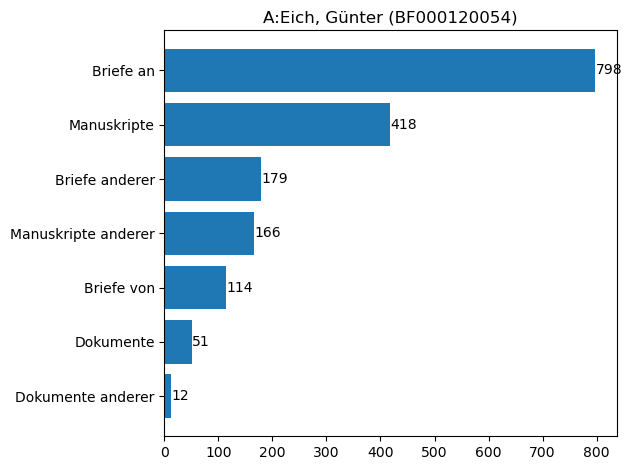

In [11]:
labels, values = zip(*Counter(r["category"] for r in records if "category" in r).most_common())
bars = plt.barh(labels, values)
plt.gca().invert_yaxis()
plt.bar_label(bars, fmt="%d")
plt.title("A:Eich, Günter (BF000120054)")
plt.tight_layout()
plt.show()

## filterLanguageType_mv

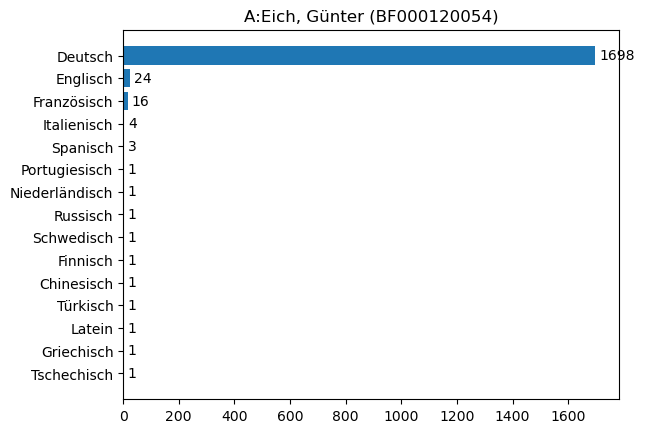

In [12]:
labels, values = zip(*Counter(
    s.replace("␝Original", "")
    for r in records
    for s in r.get("filterLanguageType_mv", [])
).most_common())

bars = plt.barh(labels, values)
plt.gca().invert_yaxis()
plt.bar_label(bars, padding=3)
plt.title("A:Eich, Günter (BF000120054)")
plt.show()

## filterLocationType_mv

In [35]:
counter = Counter()
for record in records:
    counter.update(record.get("filterLocationType_mv", []))
for value, count in counter.most_common():
    print(f"{count:5d}  {value.split('␝', 1)[0]}")

  143  München
   59  Hamburg
   49  Frankfurt am Main
   47  Berlin
   38  Geisenhausen
   30  Stuttgart
   27  Lenggries
   21  Wien
   21  Hannover
   15  Köln
   13  Bayerisch Gmain
   13  Ulm
   13  Tübingen
   12  Düsseldorf
   11  Rom
   11  Nürnberg
   11  Darmstadt
   10  Zürich
   10  Mainz
    9  Baden-Baden
    9  Freiburg im Breisgau
    9  Braunschweig
    9  Bonn
    8  Breitbrunn am Chiemsee
    8  Heidelberg
    8  Essen
    7  Paris
    7  Gütersloh
    7  Bethel (Bielefeld)
    7  Basel
    7  Gelsenkirchen-Buer
    7  Bochum
    6  Esslingen
    6  Kassel
    6  Göttingen
    5  New York, NY
    5  Linz
    5  Stockholm
    5  Bremen
    4  Köln-Müngersdorf
    4  Karlsruhe
    4  Wuppertal
    4  Dortmund
    4  Poschiavo
    4  Wiesbaden
    4  Innsbruck
    4  Kairo
    4  Kiel
    4  Erlangen
    3  Tokio
    3  Würzburg
    3  Wuppertal-Barmen
    3  London
    3  Berlin (West)
    3  Hamburg-Blankenese
    3  Sankt Gallen
    3  Graz
    3  Beuel-Ramersdorf
  

In [36]:
import folium, time, json
from geopy.geocoders import Nominatim

geolocator = Nominatim(user_agent="dla-map")
m = folium.Map(location=[48.2, 16.3], zoom_start=4, tiles="OpenStreetMap")
seen = set()

for record in records:
    for value in record.get("filterLocationType_mv", []):
        place = value.split("␝", 1)[0]

        if place in seen:
            continue
        seen.add(place)

        try:
            location = geolocator.geocode(place)
            if location:
                folium.Marker(
                    [location.latitude, location.longitude],
                    popup=place
                ).add_to(m)
                print(place, location.latitude, location.longitude)

            time.sleep(1) # Nominatim verlangt Pausen zwischen Anfragen

        except Exception as e:
            print(place, e)

m.save("orte_eich.html")

Lenggries 47.6831625 11.5763967
Seeshaupt 47.8221754 11.2694814
Bayerisch Gmain 47.7194842 12.8980967
Geisenhausen 48.4626638 12.2627122
Köln-Müngersdorf 50.940496 6.8793823
Riedlingen 48.1534412 9.4748796
Paris 48.8534951 2.3483915
Birmingham 52.4948994 -1.8518439
Rom 41.8933203 12.4829321
Dijon 47.3215806 5.0414701
Günzburg 48.4689783 10.2745279
Tokio 35.6768601 139.7638947
Bangkok 13.7524938 100.4935089
Damaskus 33.5130695 36.3095814
Brixen 46.716413 11.657792
Dürnstein 48.3953879 15.5203111
Breitbrunn am Chiemsee 47.8904604 12.400385
Köln HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Max retries exceeded with url: /search?q=K%C3%B6ln&format=json&limit=1 (Caused by ReadTimeoutError("HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Read timed out. (read timeout=1)"))
Rodrigo 22.6852106 -80.1913473
Würzburg HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Max retries exceeded with url: /search?q=W%C3%BCrzburg&format=json&limit=1

Princeton, NJ 40.3496953 -74.6597376
Telgte 51.983522 7.784859
Bonn 50.7352621 7.1024635
Esslingen am Neckar 48.7427584 9.3071685
Chieming 47.8942626 12.5381465
Pfullingen 48.4656748 9.2254982
Meersburg 47.6955538 9.2719656
Solingen-Foche 51.1944199 7.0660421
Reutlingen 48.4919508 9.2114144
Köln-Nippes 50.9589937 6.9417766
Kiel 54.3227085 10.135555
Siegburg 50.7928332 7.2070774
Alpirsbach 48.3456021 8.4033079
Zwolle 52.5089759 6.0943765
Groningen 53.2190652 6.5680077
Amsterdam 52.3730796 4.8924534
Liezen 47.5070965 14.2125684
Regis-Breitingen 51.0889296 12.4396124
Bremerhaven 53.5505392 8.5851945
Konstanz 47.659216 9.1750718
Todtnauberg 47.8516814 7.9420935
Eckernförde 54.4716456 9.8374947
Bad Godesberg 50.6850682 7.156323
Poberow 54.0570808 14.9332546
Sulzbach-Rosenberg 49.4992468 11.7470259
Athen 37.9755648 23.7348324
Jena 50.9281717 11.5879359
Düsseldorf-Himmelgeist 51.1683369 6.8055675
Hiroshima 34.3917241 132.4517589
Rosenheim 47.8557873 12.1272983
Hannover-Ricklingen 52.3340256 9

## dateOriginStart und dateOriginEnd

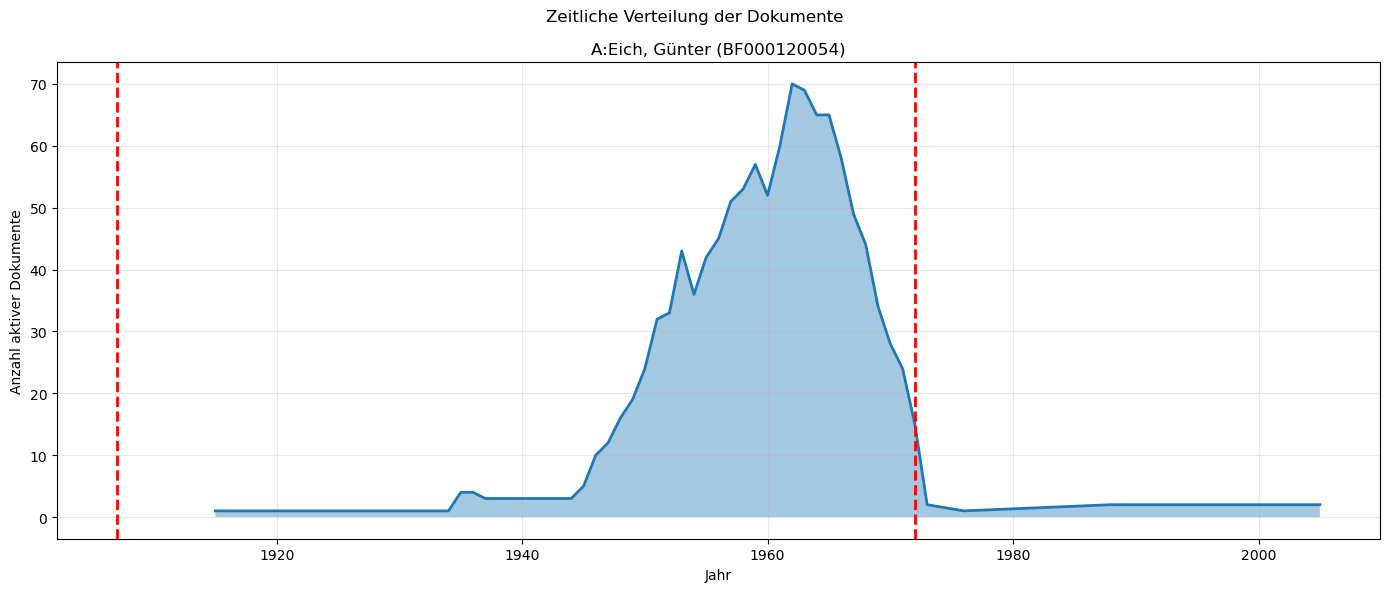

In [15]:
from collections import Counter
import matplotlib.pyplot as plt

counter = Counter()

for record in records:

    start = record.get("dateOriginStart")
    end = record.get("dateOriginEnd")

    if start and start.isdigit():

        start = int(start)

        if end and end.isdigit():
            end = int(end)
        else:
            end = start

        for year in range(start, end + 1):
            counter[year] += 1

years = sorted(counter)
values = [counter[y] for y in years]

plt.figure(figsize=(14,6))
plt.fill_between(years, values, alpha=0.4)
plt.plot(years, values, linewidth=2)

plt.xlabel("Jahr")
plt.ylabel("Anzahl aktiver Dokumente")
plt.title("A:Eich, Günter (BF000120054)")
plt.suptitle("Zeitliche Verteilung der Dokumente")
plt.axvline(x=1907, color='r', linestyle='--', linewidth=2)
plt.axvline(x=1972, color='r', linestyle='--', linewidth=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## genre Feld

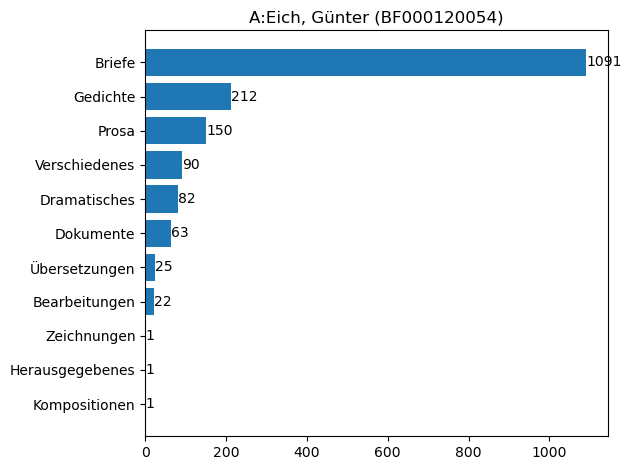

Übersetzungen:
–  Valentin, Anne: Sabeth [Übersetzungen]
–  Friebert, Stuart: Sammlung Valuable Nail. Selected Poems [Übersetzungen]
–  Valentin, Anne: L'Autre et Moi. Conte pour la radio [Übersetzungen]
–  Rohatyn-Blau, Rita: Cauchemar [Übersetzungen]
–  Snijers, Nora: Dromen [Übersetzungen]
–  Verschiedene <Studenten>: Konvolut Gedichte [Übersetzungen]
–  Vega, Rafael de la: Konvolut 2 Gedichte [Übersetzungen]
–  Unbekannt: Sammlung Botschaften des Regens [Übersetzungen]
–  Enqvist, Heikki: Sammlung Botschaften des Regens [Übersetzungen]
–  Niederau, Kurt: Konvolut Gedichte [Übersetzungen]
–  Rohatyn-Blau, Rita: Parfois [Übersetzungen]
–  Hamburger, Michael: Sammlung Botschaften des Regens [Übersetzungen]
–  Zimmermann, Albrecht: aus Sammlung Botschaften des Regens [Übersetzungen]
–  Watkins, Vernon: Think of this [Übersetzungen]
–  Schwebell, Gertrude Clorius: Konvolut 4 Gedichte [Übersetzungen]
–  Lutze, Lothar: Konvolut Gedichte [Übersetzungen]
–  Lohner, Edgar: Eich, Günter: Gedi

In [16]:
labels, values = zip(*Counter(r["genre"] for r in records if "genre" in r).most_common())
bars = plt.barh(labels, values)
plt.gca().invert_yaxis()
plt.bar_label(bars, fmt="%d")
plt.title("A:Eich, Günter (BF000120054)")
plt.tight_layout()
plt.show()

print("Übersetzungen:")
for rec in records:
    try:
        if rec["genre"]=="Übersetzungen":
            print('– ', rec["title"])        
    except:
        continue

## filterFormContent_mv

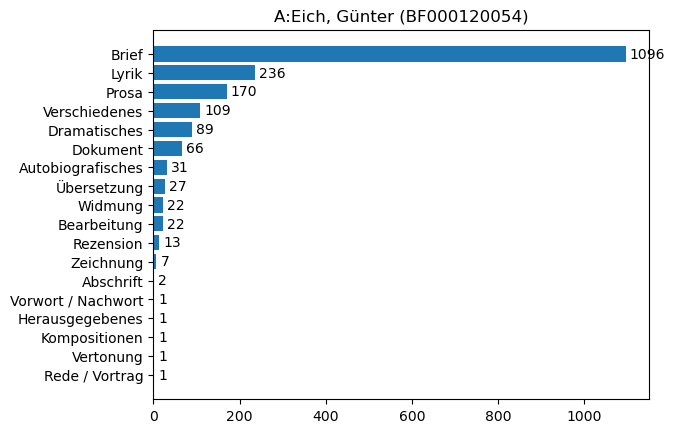

In [17]:
labels, values = zip(*Counter(
    s.replace("␝Original", "")
    for r in records
    for s in r.get("filterFormContent_mv", [])
).most_common())

bars = plt.barh(labels, values)
plt.gca().invert_yaxis()
plt.bar_label(bars, padding=3)
plt.title("A:Eich, Günter (BF000120054)")
plt.show()

## dateCataloged und dateModified

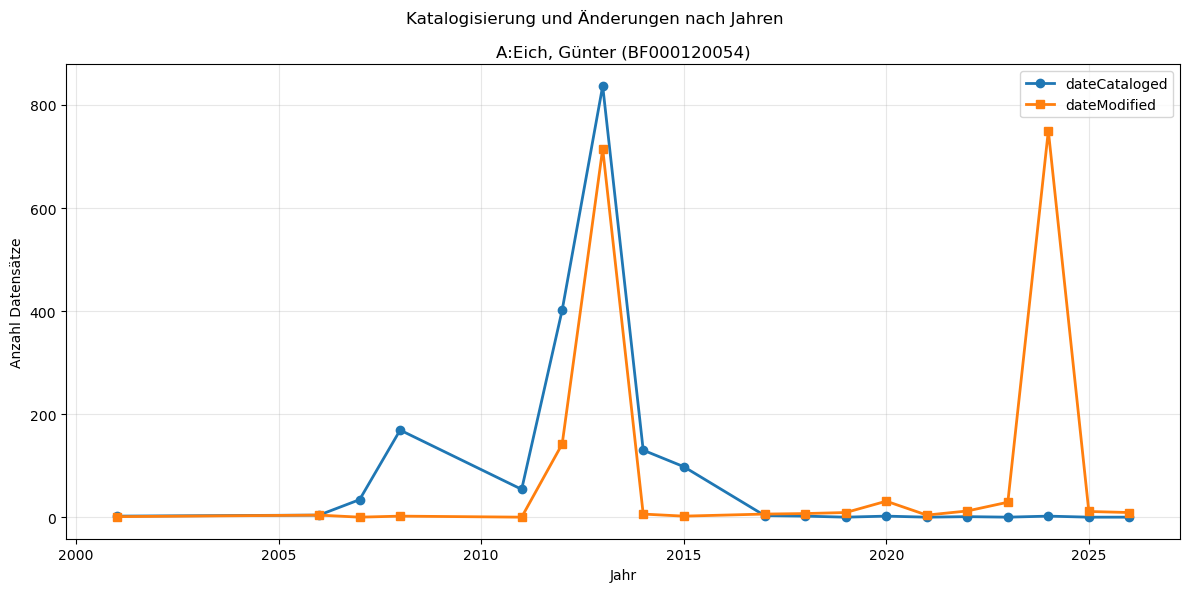

In [18]:
cataloged = Counter()
modified = Counter()

# Jahre zählen
for record in records:
    d = record.get("dateCataloged")
    if d:
        cataloged[int(d[:4])] += 1
    d = record.get("dateModified")
    if d:
        modified[int(d[:4])] += 1

# Gemeinsame Jahresachse
years = sorted(set(cataloged) | set(modified))

cataloged_values = [cataloged[y] for y in years]
modified_values = [modified[y] for y in years]

# Diagramm
plt.figure(figsize=(12, 6))

plt.plot(years, cataloged_values,
         marker="o",
         linewidth=2,
         label="dateCataloged")

plt.plot(years, modified_values,
         marker="s",
         linewidth=2,
         label="dateModified")

plt.xlabel("Jahr")
plt.ylabel("Anzahl Datensätze")
plt.title("A:Eich, Günter (BF000120054)")
plt.suptitle("Katalogisierung und Änderungen nach Jahren")

plt.xticks()
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

**Anm.:** Im Jahr 2024 wurden die Daten der retrodigitalisierten Karteikarten korrigiert.

### Welche Einheiten wurden 2024 modifiziert?

#### Antwort: vor allem Briefe (500), von und an Günter Eich (286 bzw. 351)

In [92]:
genre=Counter()
for record in records:
    try:
        if int(record.get("dateModified")[:4])==2024:
            genre.update( record["filterFormContent_mv"] )
    except:
        continue
print( genre.most_common(3) )

[('Brief', 500), ('Lyrik', 114), ('Prosa', 69)]


In [93]:
namen_von = Counter()
namen_an = Counter()
for record in records:
    try:
        if int(record.get("dateModified")[:4])==2024:
            namen_von.update(record["searchNameBy_mv"])
            namen_an.update(record["searchNameTo_mv"])
        #print( int(record.get("dateModified")[:4]) )
    except:
        continue
print("Von:", namen_von.most_common(2))
print("An:", namen_an.most_common(3))

Von: [('Eich, Günter', 286), ('Moras, Joachim', 10)]
An: [('Eich, Günter', 351), ('Aichinger, Ilse', 101), ('Brambach, Rainer', 26)]


## display

In [94]:
counter = Counter()

for record in records:
    display = record.get("display")
    if display:
        counter[display] += 1

for display, count in counter.most_common():
    print(f"{count:5d}  {display}")

   21  Eich, Günter an Brambach, Rainer [Briefe]
   10  Moras, Joachim an Eich, Günter [Briefe]
    9  Richter, Hans Werner an Eich, Günter [Briefe]
    8  Eich, Günter: Notizen [Verschiedenes]
    8  Eich, Günter: Leip, Hans: Prosa "Jan Himp und die kleine Brise. Roman" [Bearbeitungen]
    7  Eich, Günter: Die Mädchen aus Viterbo [Dramatisches]
    7  Aichinger, Ilse an Eich, Günter [Briefe]
    7  Süddeutscher Rundfunk an Eich, Günter [Briefe]
    7  Podewils, Clemens an Eich, Günter [Briefe]
    6  Brambach, Rainer: Konvolut Gedichte [Gedichte]
    6  Schwitzke, Heinz an Eich, Günter [Briefe]
    6  Prager, Gerhard an Eich, Günter [Briefe]
    5  Eich, Günter: Sabeth [Dramatisches]
    5  Nordwestdeutscher Rundfunk an Eich, Günter [Briefe]
    5  Norddeutscher Rundfunk an Eich, Günter [Briefe]
    5  Mundt, Hans Josef an Eich, Günter [Briefe]
    5  Aicher-Scholl, Inge an Eich, Günter [Briefe]
    4  Eich, Günter an Brambach, Claire [Briefe]
    4  Brambach, Rainer an Eich, Günter [